### Importamos librerias

In [39]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Exploración de archivos
import sys
import os

# Funciones personalizadas
sys.path.append(os.path.abspath('../src'))
import sp_eda as se

# Visualizaciones
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

### Para mostrar todas las columnas

In [40]:
pd.set_option('display.max_columns', None)

### Cargamos el conjunto de datos sales_final desde el archivo CSV

In [41]:
df_eda = pd.read_csv('../data/processed/sales_final.csv', parse_dates=['SalesDate'])

### Análisis Exploratorio de Datos

##### Objetivos del EDA:

El objetivo principal del EDA es comprender la estructura del dataset, identificar patrones relevantes en las ventas y detectar posibles anomalías o comportamientos atípicos que puedan influir en el análisis posterior.

A través del análisis descriptivo se busca responder preguntas clave relacionadas con el rendimiento comercial, el comportamiento de los clientes y la dinámica temporal de las ventas.

##### Preguntas Claves a Investigar:

1. ¿Cómo se distribuyen los ingresos?

2. ¿Qué productos y categorías generan mayor Ingreso Total?

3. ¿Cómo influyen los descuentos en el comportamiento de compra?

4. ¿Existen patrones temporales en las ventas?

5. ¿Donde se generan los valores más altos de ventas?


### Análisis descriptivo: Columnas numéricas

In [42]:
se.descriptivo_num(df_eda)

Variables numéricas son:
 Index(['SalesID', 'SalesPersonID', 'CustomerID', 'Quantity', 'Discount',
       'TotalPrice', 'SalesDate', 'Price', 'VitalityDays', 'RevenueBruto',
       'DiscountAmount', 'MonthNum'],
      dtype='object')

Las estadísticas básicas:


,count,mean,min,25%,50%,75%,max,std
SalesID,6690599.0,3379160.42,1.0,1689668.5,3379225.0,5068618.5,6758125.0,1950887.3
SalesPersonID,6690599.0,12.0,1.0,6.0,12.0,18.0,23.0,6.63
CustomerID,6690599.0,49395.04,1.0,24703.0,49413.0,74077.0,98759.0,28506.14
Quantity,6690599.0,13.0,1.0,7.0,13.0,19.0,25.0,7.21
Discount,6690599.0,0.03,0.0,0.0,0.0,0.0,0.2,0.06
TotalPrice,6690599.0,641.08,0.04,180.65,490.77,983.74,2496.89,547.08
SalesDate,6690599,2018-03-06 12:28:36.599014144,2018-01-01 00:00:04.070000,2018-02-02 06:29:42.464999936,2018-03-06 13:05:36.860000,2018-04-07 18:07:28.464999936,2018-05-09 23:59:59.400000,NaN
Price,6690599.0,50.83,0.04,26.58,52.64,75.25,99.88,28.57
VitalityDays,6690599.0,26.03,0.0,0.0,0.0,52.0,120.0,39.02
RevenueBruto,6690599.0,660.88,0.04,186.78,507.33,1017.35,2496.89,561.05


Observaciones de los datos numericos:

- **SalesID**: Número de transacciones: 6.690.599
- **SalesPersonID**: Al estar la media y la mediana casi en el mismo punto, significa que IDs de vendedor están distribuidos uniformemente.
- **CustomerID**: CustomerID promedio = 49.395, máximo = 98.759. Amplia variedad de clientes.La desviación estándar es de 28.506. Esto indica que las ventas están bien distribuidas entre toda la base de datos de clientes
- **Quantity**: El promedio (mean) de productos vendidos por transacción es de 13 unidades. La mediana (50%) también es 13, desviación estándar = 7.21 lo que indica una distribución muy equilibrada, sin valores atípicos fuertes.
- **Discount**: Tasa de descuento promedio: 3% (mediana = 0%) lo que significa que la mayoría de las ventas son sin descuento, pero hay grandes descuentos de hasta el 20%.
- **TotalPrice**: Importe promedio de venta = 641.08, mediana = 490.77, desviación estándar = 547.08. Se observan transacciones grandes, lo que crea una distribución del lado derecho.
- **SalesDate**: Los datos cubren desde el 1 de enero de 2018 hasta el 9 de mayo de 2018.
- **Price**: El precio medio del producto es de 50.83, con un rango de 0.04 a 99.88. Como la media y la mediana están muy cerca (50.83 vs 52.64), podemos decir que la distribución es bastante simétrica.
- **VitalityDays**: Media = 26.03, mediana = 0, máx = 120, std = 39. La mayoría de los productos tienen una vida útil corta, pero hay productos con una vida útil larga (120 días).
- **RevenueBruto**: El valor promedio es 660.88, que está ligeramente por encima del promedio de TotalPrice, mostrando un efecto moderado de los descuentos. Los valores atípicos observados en TotalPrice y RevenueBruto son generados principalmente por transacciones con grandes volúmenes de compra o productos de alto precio.
- **DiscountAmount**: Descuento promedio = 19.8, máximo: 499.38. La mayoría de las ventas se realizan sin descuentos significativos, pero los grandes descuentos poco frecuentes generan outliers.

### Histogramas:

Distribución de la columna *Quantity*


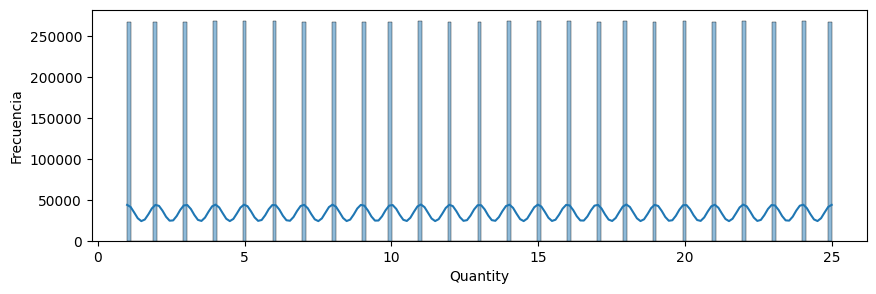

Distribución de la columna *Discount*


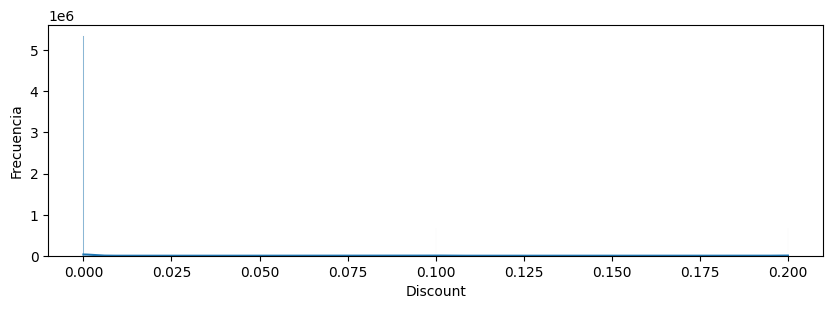

Distribución de la columna *TotalPrice*


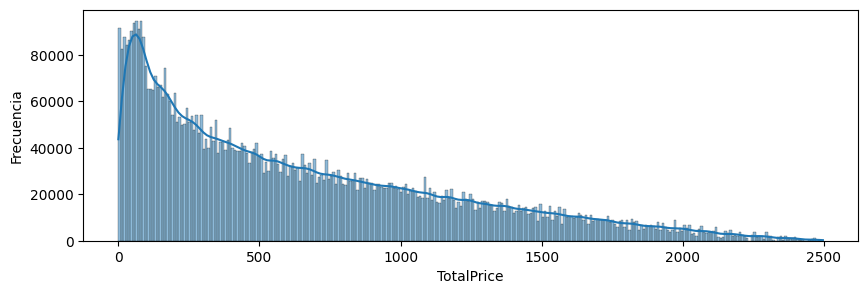

Distribución de la columna *Price*


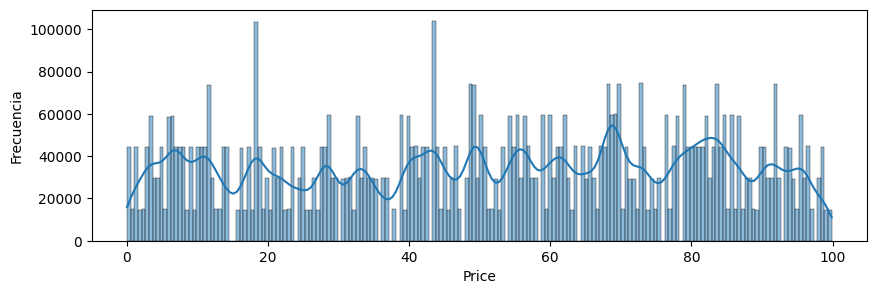

Distribución de la columna *VitalityDays*


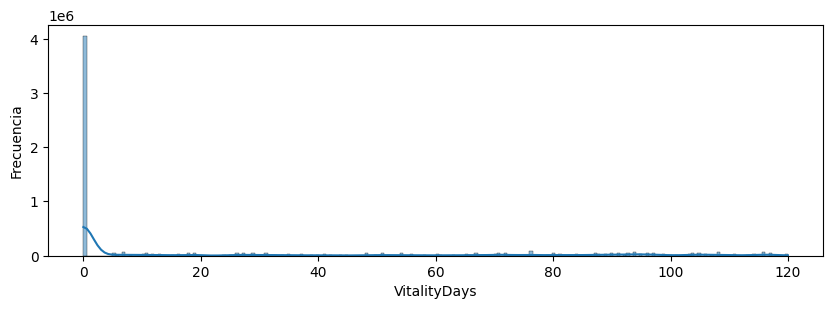

Distribución de la columna *RevenueBruto*


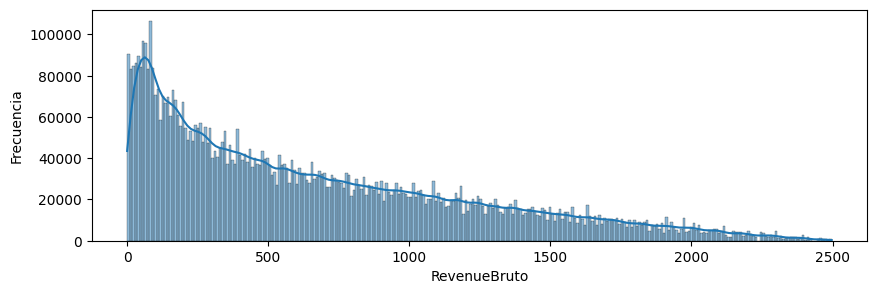

Distribución de la columna *DiscountAmount*


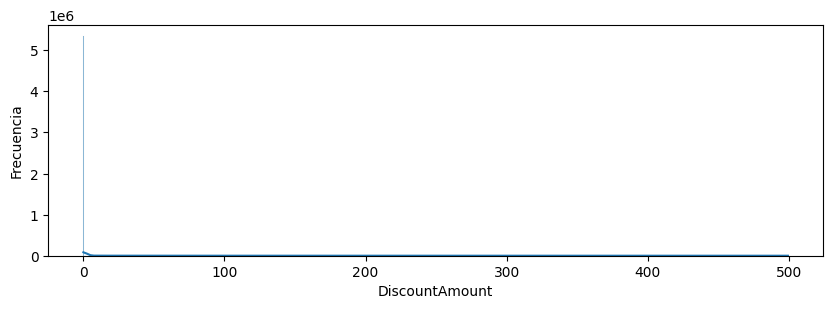

In [43]:
se.histplot_num(df_eda)

### Boxplots:

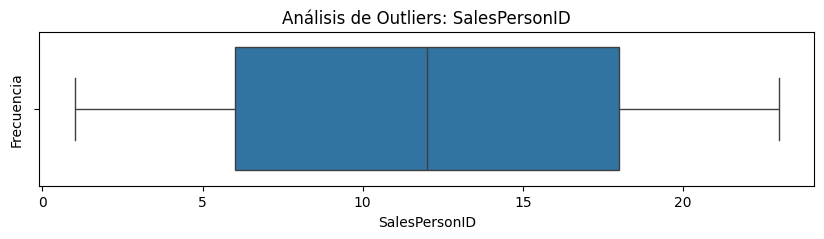

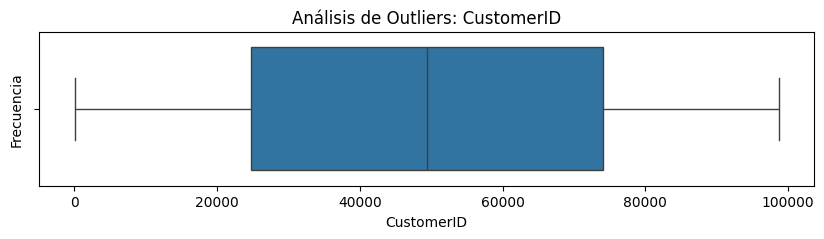

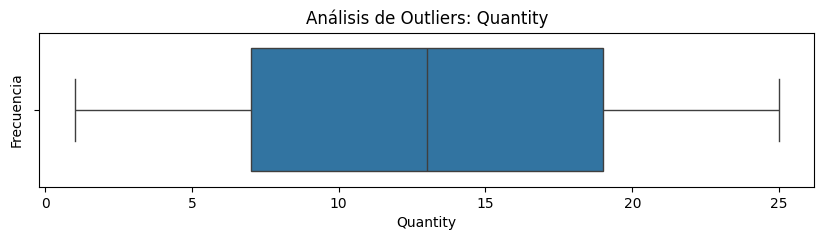

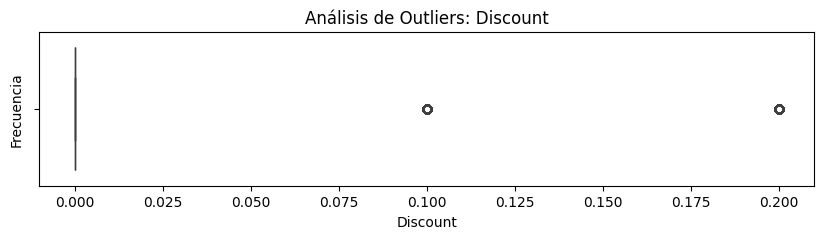

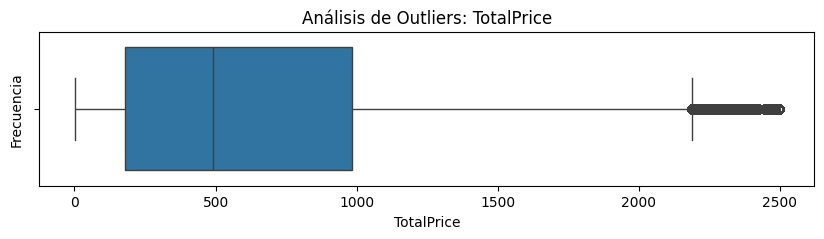

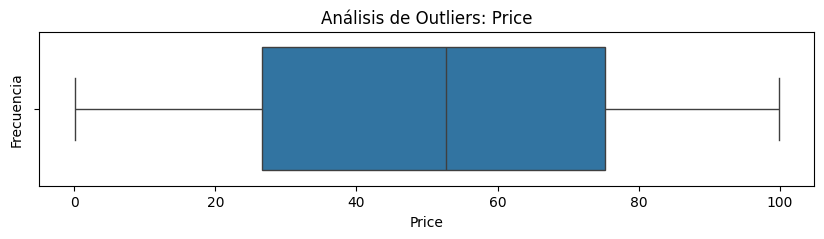

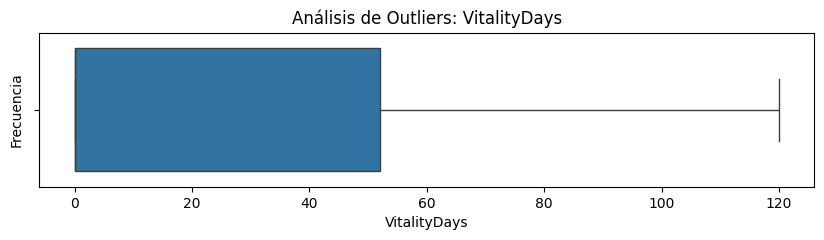

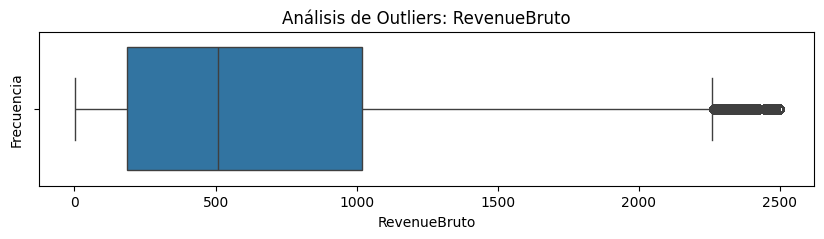

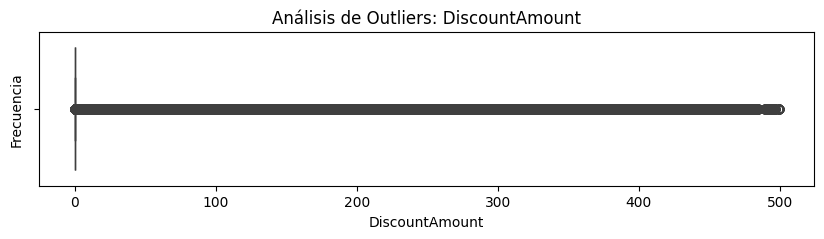

In [44]:
se.boxplots_num(df_eda)

### Análisis descriptivo: Columnas categóricas

In [45]:
se.descriptivo_cat(df_eda)

Variables categoricas son:
 Index(['ProductName', 'Class', 'Resistant', 'IsAllergic', 'CityName',
       'CountryName', 'CategoryName', 'Month', 'DayOfWeek'],
      dtype='object')

Las estadísticas básicas:


,count,unique,top,freq
ProductName,6690599,452,Longos - Chicken Wings,15215
Class,6690599,3,Medium,2309073
Resistant,6690599,3,Durable,2427000
IsAllergic,6690599,3,False,2441288
CityName,6690599,96,Tucson,74904
CountryName,6690599,1,United States,6690599
CategoryName,6690599,11,Confections,843466
Month,6690599,5,March,1609190
DayOfWeek,6690599,7,Wednesday,985464


La columna *ProductName* tiene 452 valores unicos:
Los 10 valores con más frequencia son:


ProductName
Longos - Chicken Wings     15215
Cream Of Tartar            15154
Rambutan                   15105
Wine - Redchard Merritt    15095
Table Cloth 54x72 White    15087
Beans - Kidney White       15078
Clam Nectar                15068
Dried Figs                 15063
Yoghurt Tubes              15058
Arizona - Green Tea        15056
Name: count, dtype: int64

La columna *Class* tiene 3 valores unicos:
Los 10 valores con más frequencia son:


...

CategoryName
Confections    843466
Meat           740223
Poultry        697205
Cereals        665059
Produce        636392
Beverages      563517
Snails         548123
Seafood        532207
Shell fish     532149
Dairy          518600
Name: count, dtype: int64

La columna *Month* tiene 5 valores unicos:
Los 10 valores con más frequencia son:


Month
March       1609190
January     1607050
April       1556091
February    1451366
May          466902
Name: count, dtype: int64

La columna *DayOfWeek* tiene 7 valores unicos:
Los 10 valores con más frequencia son:


DayOfWeek
Wednesday    985464
Tuesday      985367
Monday       984734
Friday       934577
Sunday       933803
Thursday     933420
Saturday     933234
Name: count, dtype: int64

Observaciones de los datos categóricos:
- **ProductName** Una amplia variedad de productos. El producto más popular no domina en exceso (15k из 6,6M ≈ 0,23%), lo que indica que ventas están muy repartidas entre muchos productos (no dependes de uno solo).
- **Class** Tienes 3 tipos, pero la clase "Medium" es la más frecuente (2.3 millones de veces).
- **Resistant** También 3 tipos, siendo la categoría "Durable" la moda (2.4 millones).
- **IsAllergic** La gran mayoría de los productos (2.4 millones) están marcados como "False" (no contienen alérgenos comunes o no están etiquetados como tales).
- **CityName** Hay presencia en 96 ciudades. Tucson es el mercado más activo, con 74.904 transacciones.
- **CountryName** Operan exclusivamente en United States. El análisis geográfico se realizará a nivel de ciudades.
- **CategoryName** La categoría dominante es Confections (Dulces/Golosinas) con 843.466. Esto sugiere que, aunque las alitas de pollo (Longos - Chicken Wings) se venden mucho individualmente, el volumen real de movimiento está en la sección de confitería.
- **Month** El pico de actividad (o el mes con más registros en este dataset) es Marzo (1.6 millones de filas).
- **DayOfWeek** El día de semana con mayor volumen de ventas es el Miércoles (985.464 filas).

Podemos describir una "venta típica" basándonos solo en la moda (lo más frecuente):
Una venta de Confitería realizada un Miércoles de Marzo en la ciudad de Tucson, de un producto de clase Medium y Durable.

### Countplots:

Distribución de la columna *ProductName*


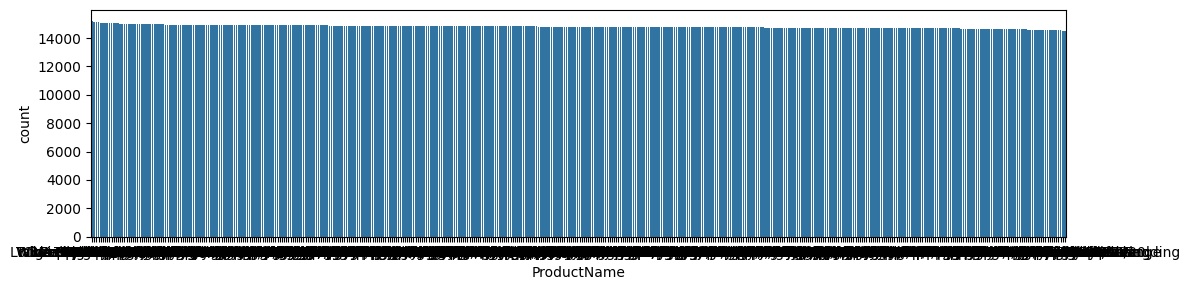

Distribución de la columna *Class*


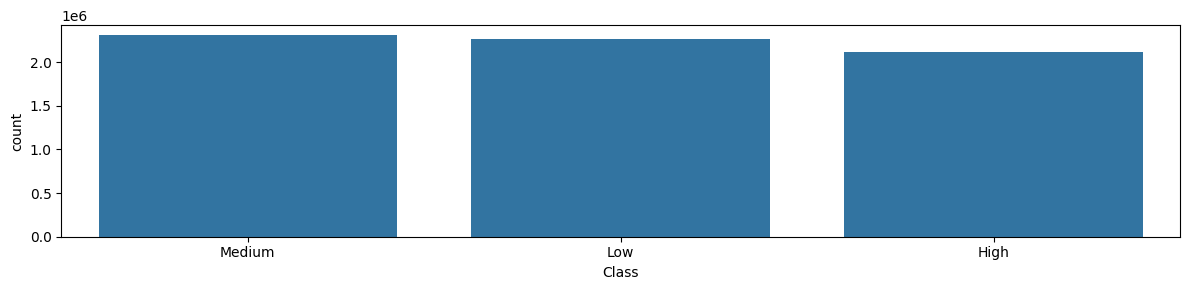

Distribución de la columna *Resistant*


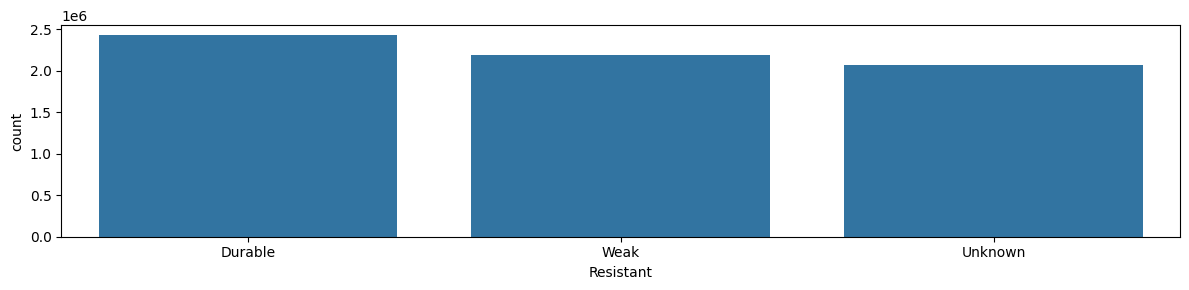

Distribución de la columna *IsAllergic*


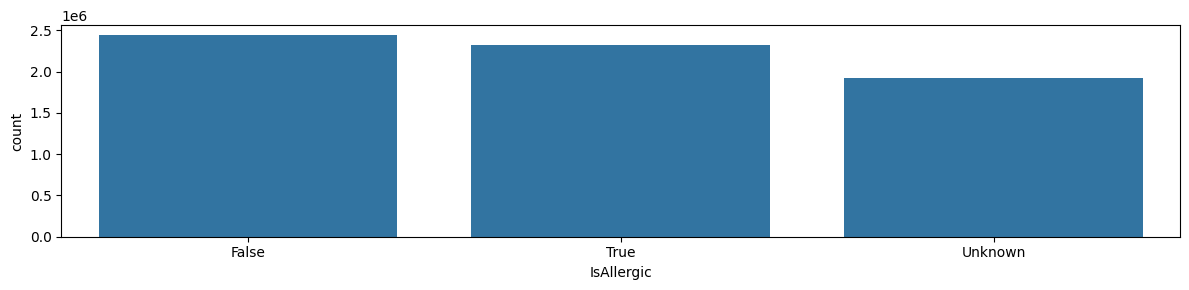

Distribución de la columna *CityName*


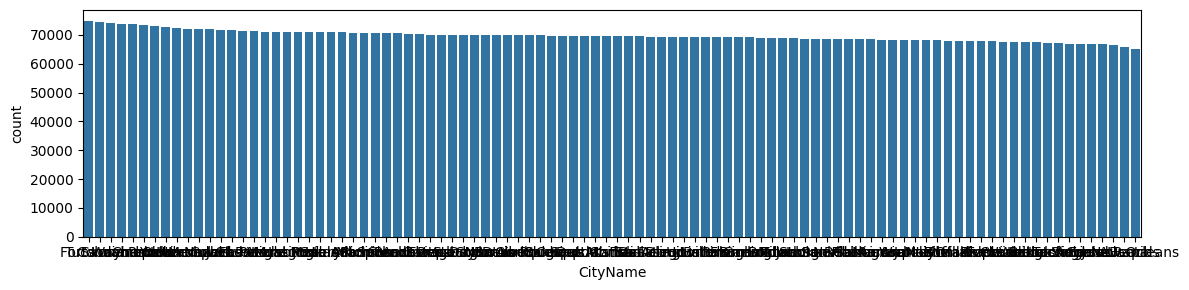

Distribución de la columna *CountryName*


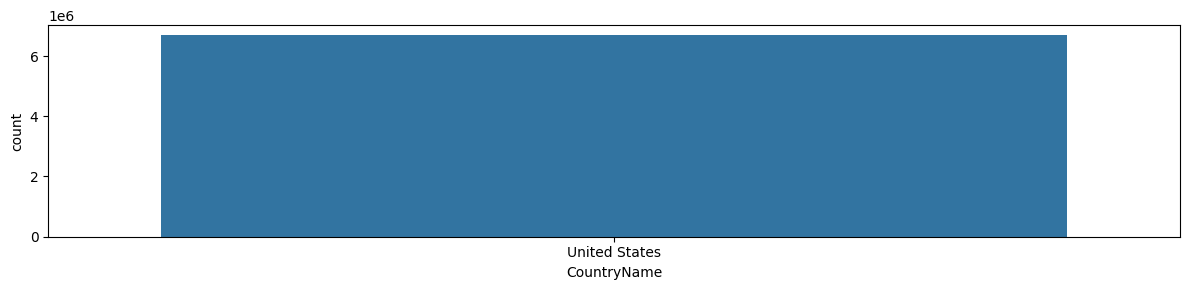

Distribución de la columna *CategoryName*


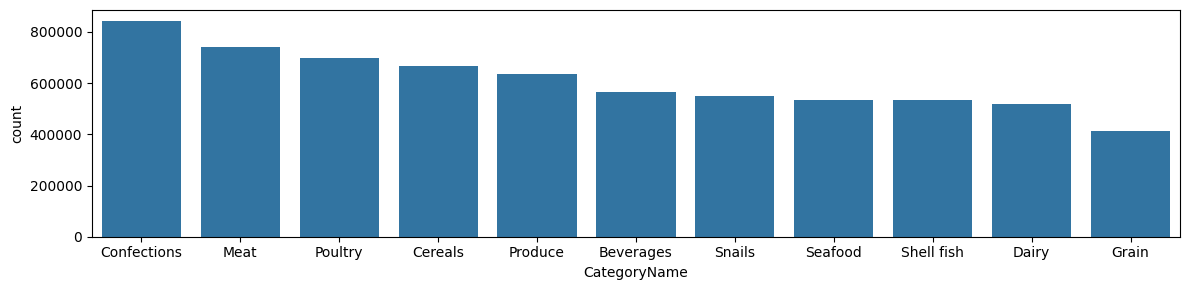

Distribución de la columna *Month*


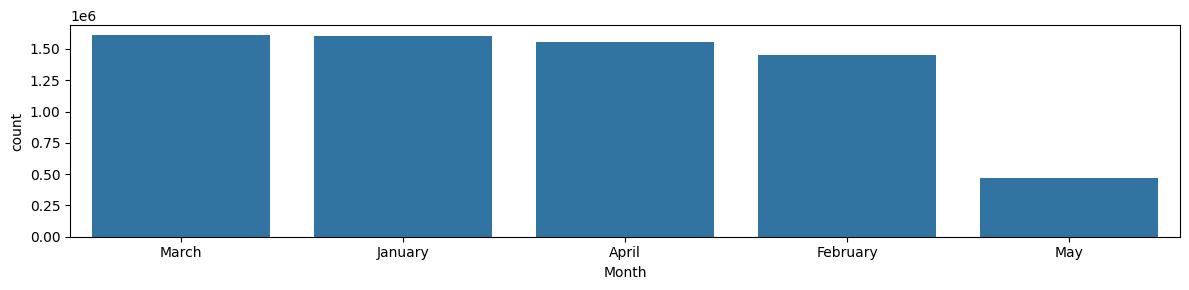

Distribución de la columna *DayOfWeek*


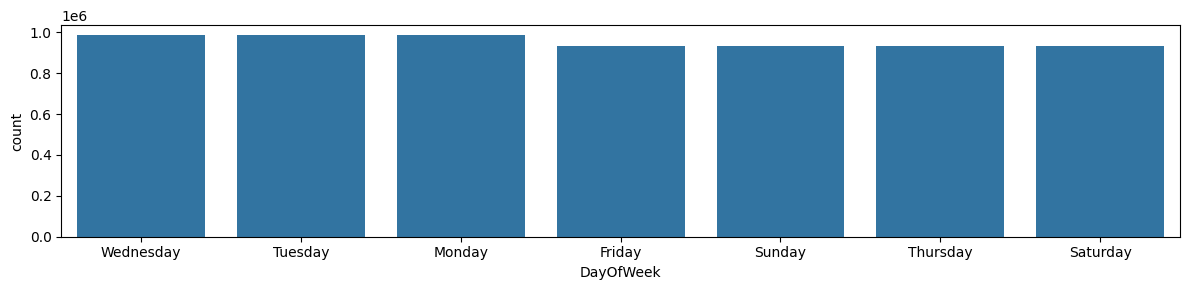

In [46]:
se.countplot_cat(df_eda, 500)

### Matriz de correlación

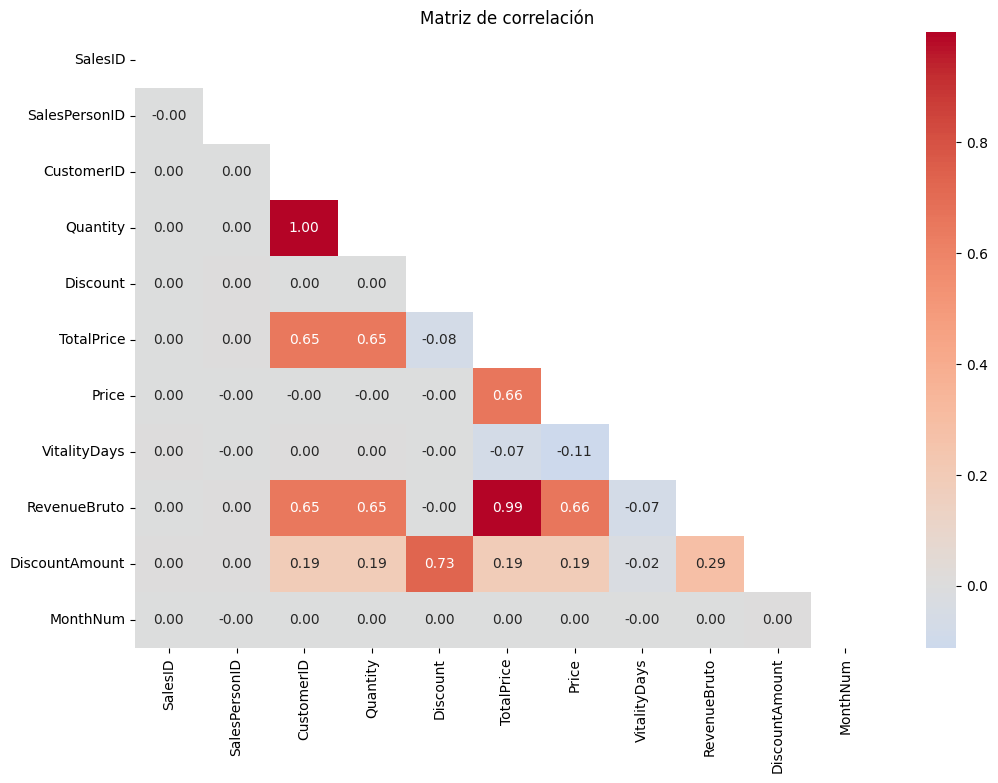

In [47]:
se.correlaciones(df_eda)

### Los hallazgos más importantes de la matriz de correlación:

1. Correlaciones Positivas

**Quantity y CustomerID (1.00)**: Sugiere que el ID del cliente y la cantidad de productos están perfectamente alineados en el dataset.Podría ser un error de carga de datos o que el CustomerID se asignó basándose en la cantidad. La correlación debe ser investigada.

**TotalPrice y RevenueBruto (0.99):**: Esto confirma que el ingreso bruto depende directamente del precio total de la venta. 

**Discount vs DiscountAmount (0.73)**: Es lógico, a mayor porcentaje de descuento, mayor es el monto descontado en dinero.

**RevenueBruto y Price (0.66)**, **TotalPrice y Price (0.66)**: Existe una correlación positiva moderada-fuerte. Esto indica que los ingresos dependen más de vender productos caros que de otros factores.

**RevenueBruto y Quantity (0.65)**, **TotalPrice y Quantity (0.65)**: La cantidad también tiene un peso importante. Las ventas crecen de forma equilibrada tanto por vender más volumen como por vender productos de mayor precio.

**DiscountAmount y RevenueBruto (0.29)**: Indica una correlación positiva débil, el descuento no es el principal motor de las ventas.Como vimos en los estadísticos descriptivos, más del 75% de las ventas tienen descuento 0. Esto explica por qué la correlación es tan baja: para la gran mayoría de los datos el descuento no existe y no afecta al ingreso.

**DiscountAmount y TotalPrice (0.19)**: Es aún más baja que la anterior (0.29), lo que refuerza la idea de que los descuentos tienen una influencia muy limitada en el valor final de las ventas. 

2. Correlaciones Nulos y ligeramente negativos

**VitalityDays**: No tiene correlación relevante con ninguna otra variable (valores cercanos a 0.00 o ligeramente negativos como -0.11 con Price). Los clientes no prestan mucha atención a la "vitalidad" del producto al momento de comprar.

**SalesPersonID y SalesID (0.00)**: Confirma que los números de identificación son aleatorios y no influyen en el comportamiento del negocio.

Concluciones: 

La matriz de correlación muestra que los principales impulsores del revenue son la cantidad vendida y el precio del producto. Los descuentos tienen un impacto moderado y no representan el principal factor de generación de ingresos. TotalPrice y RevenueBruto son duplicados en términos de correlación. Sin embargo, se detecta una anomalía crítica: la correlación (1.00) entre CustomerID y Quantity, y debe ser investigada.



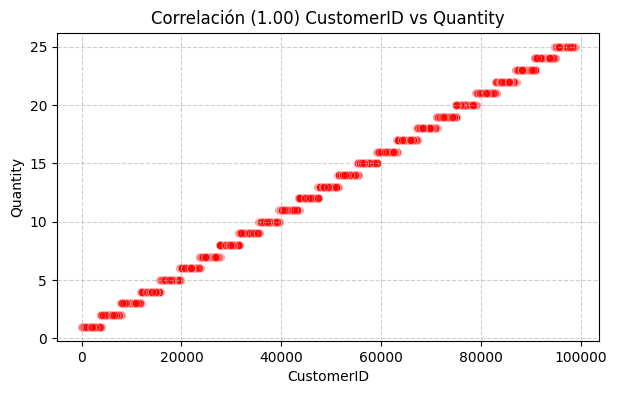

In [48]:
# Investigamos la anomalía del 1.00 de correlación **Quantity y CustomerID**:
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_eda, x='CustomerID', y='Quantity', alpha=0.5, color='red')
plt.title('Correlación (1.00) CustomerID vs Quantity')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [49]:
df_eda[['CustomerID','Quantity']].head(10)

,CustomerID,Quantity
0,27039,7
1,25011,7
2,94024,24
3,73966,19
4,32653,9
5,28663,8
6,46674,12
7,12687,4
8,89009,23
9,65017,17


In [50]:
df_eda[['CustomerID','Quantity']].corr()

,CustomerID,Quantity
CustomerID,1.000000,0.999199
Quantity,0.999199,1.000000


Explicación de anomalia de correlación Quantity y CustomerID (1.00):

Es muy probable que la columna CustomerID sea la que fue generada a partir de Quantity.
En el scatter plot los puntos no son una línea continua, sino bloques horizontales: Hay un bloque gigante de clientes (del 0 al 4.000 aprox.) que todos tienen exactamente Quantity = 1. Luego, el siguiente bloque (del 4.000 al 8.000) tiene Quantity = 2.
Desde el punto de vista empresarial, esta relación no tiene sentido lógico, ya que la cantidad comprada no debería determinar el identificador del cliente. Esto sugiere que la variable CustomerID fue generada de manera estructural o dependiente del Quantity.
En nuestro analisis ignoramos la variable 'CustomerID'.

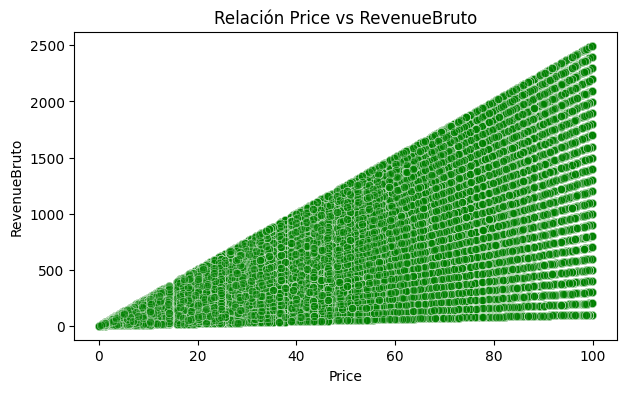

In [51]:
# Análisis de Ingresos: Price vs RevenueBruto
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_eda, x='Price', y='RevenueBruto', alpha=0.4, color='green')
plt.title('Relación Price vs RevenueBruto')
plt.show()

La correlación Precio y Ingreso Bruto (0.66). El gráfico verde muestra una forma de triángulo o abanico. Para cada nivel de precio, existen múltiples valores de RevenueBruto. Esto sucede porque el ingreso depende de la multiplicación de Price * Quantity. Es una relación lineal multiplicativa.

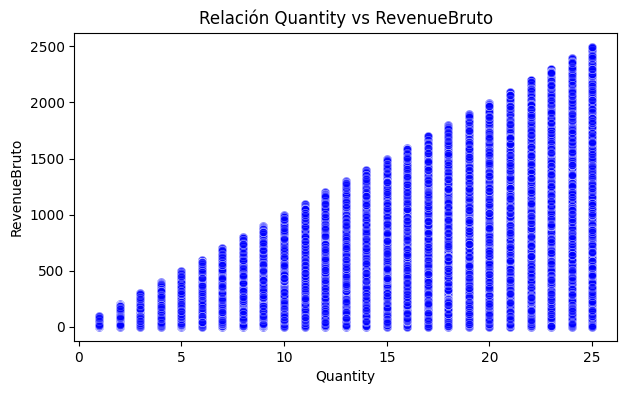

In [52]:
# Análisis de Ingresos: Quantity vs RevenueBruto
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_eda, x='Quantity', y='RevenueBruto', alpha=0.4, color='blue')
plt.title('Relación Quantity vs RevenueBruto')
plt.show()

La correlación Cantidad y Ingreso Bruto (0.65). El gráfico azul muestra líneas verticales. Confirma que la cantidad es una variable discreta. A medida que te mueves a la derecha (más cantidad), el potencial de RevenueBruto aumenta. 

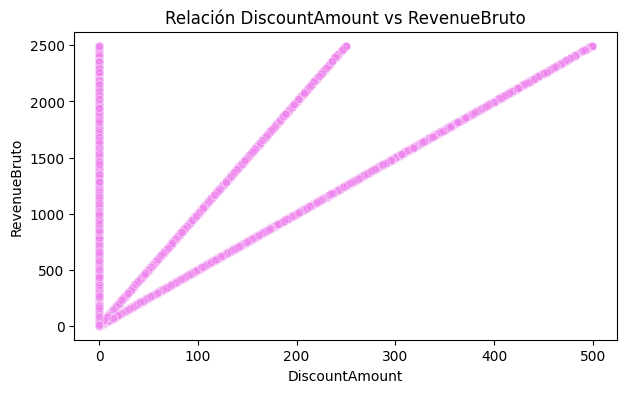

In [53]:
# Análisis de Ingresos: DiscountAmount vs RevenueBruto
plt.figure(figsize=(7, 4))
sns.scatterplot(data=df_eda, x='DiscountAmount', y='RevenueBruto', alpha=0.4, color='violet')
plt.title('Relación DiscountAmount vs RevenueBruto')
plt.show()

In [54]:
df_eda['Discount'].value_counts().unique

<bound method Series.unique of Discount
0.0    5353035
0.1     670318
0.2     667246
Name: count, dtype: int64>

La correlación Importe Descuento y Ingreso Bruto (0.29). El gráfico muestra tres líneas diagonales muy marcadas que salen del origen. Esto indica que los descuentos no se aplican de forma aleatoria, sino que existen tres reglas fijas de descuento (0%, 10% y 20%).
Línea vertical en cero representa la gran mayoría de las ventas (el 75% que vimos antes) donde el descuento es cero, pero el ingreso varía. Líneas diagonales: Representan las ventas donde se aplicó una promoción. La pendiente de cada línea es la "tasa" del descuento.

### Análisis estadístico

#### Pregunta clave 1:  ¿Cómo se distribuyen los ingresos?

El ticket promedio de TotalPrice (641.08) es superior a la mediana (490.77), lo que indica que existen transacciones de alto valor que elevan la media.

La diferencia entre media y mediana sugiere que la distribución no es simétrica. Presenta sesgo positivo (asimetría a la derecha).

Desviación Estándar (547.08) indica alta variabilidad.

Existe una diferencia considerable entre el tercer cuartil (75% : 983.74) y el valor máximo (2 496.89), lo que indica la presencia de outliers. Estas transacciones probablemente corresponden a compras en gran volumen o productos de precio elevado.  Pero la mayoría de las transacciones son de valor medio o bajo.


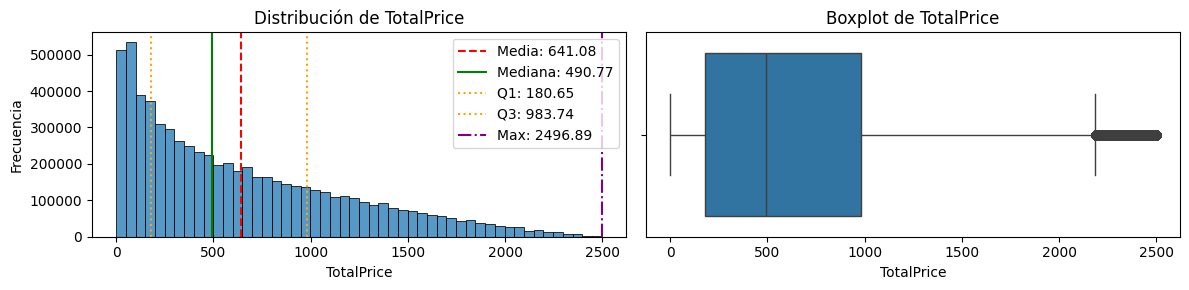

In [55]:
# Calculamos estadísticas
mean_ = df_eda['TotalPrice'].mean()
median_ = df_eda['TotalPrice'].median()
q1_ = df_eda['TotalPrice'].quantile(0.25)
q3_ = df_eda['TotalPrice'].quantile(0.75)
max_ = df_eda['TotalPrice'].max()

# Creamos gráficos para demonstrar distribucion y presencia de outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

# Histograma
sns.histplot(df_eda['TotalPrice'], bins=50, ax=axes[0])
# Líneas verticales
axes[0].axvline(mean_, color='red', linestyle='--', label=f'Media: {mean_:.2f}')
axes[0].axvline(median_, color='green', linestyle='-', label=f'Mediana: {median_:.2f}')
axes[0].axvline(q1_, color='orange', linestyle=':', label=f'Q1: {q1_:.2f}')
axes[0].axvline(q3_, color='orange', linestyle=':', label=f'Q3: {q3_:.2f}')
axes[0].axvline(max_, color='purple', linestyle='-.', label=f'Max: {max_:.2f}')

axes[0].set_title('Distribución de TotalPrice')
axes[0].set_xlabel('TotalPrice')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Boxplot
sns.boxplot(x=df_eda['TotalPrice'], ax=axes[1])
axes[1].set_title('Boxplot de TotalPrice')
axes[1].set_xlabel('TotalPrice')

plt.tight_layout()
plt.show()

#### Pregunta clave 2:  ¿Qué productos y categorías generan mayor Ingreso Total?
- **Productos** 

Distribución de ventas es muy plana. El porcentaje de ingresos totales (TotalPrice_%) es casi idéntico para todos los productos del Top 10 (oscila entre 0.43% y 0.42%).
Es notable la poca varianza entre los productos líderes. El modelo de negocio no depende de un único "producto estrella".
El Top 10 muestra una gran variedad de categorías, lo cual es típico de un inventario de suministros de alimentos: 

- Panadería: Bread - Calabrese Baguette.

- Proteínas: Shrimp (Camarones) y Beef (Carne de res).

- Frutas y Verduras: Zucchini, Vanilla Beans, Lettuce.

- Bebidas/Licores: Tia Maria, Grenadine, Pop Shoppe Cream Soda.

El análisis de concentración muestra que 252 de 452 productos (56%) generan el 80% del ingreso total (252/452=0.557≈56%). 
El principio clásico de efecto Pareto (80/20) implicaría que aproximadamente el 20% de los productos generen el 80% del ingreso total.
Esto indica que no existe un efecto Pareto marcado, ya que el ingreso está relativamente distribuido entre una amplia proporción del portafolio.

- **Categorías** 

La categoría líder es: Confections — 12.85% del ingreso. Le siguen:
Meat — 11.38%,
Poultry — 10.16%,
Cereals — 9.86% total.

Las 4 primeras categorías generan aproximadamente el 44% del ingreso total.
El análisis por categoría muestra una distribución relativamente equilibrada del ingreso.  No se observa una concentración extrema del ingreso, lo que indica una estructura de ventas diversificada y menor dependencia de una sola categoría.

### Productos:

In [56]:
# Buscamos TotalPrice por producto
top_products = (df_eda.groupby('ProductName')['TotalPrice'].sum().sort_values(ascending=False))

# Convertimos en DataFrame
top_products = top_products.reset_index()
top_products.columns = ['ProductName', 'TotalPrice']

# Calculamos porcentaje sobre el total
total_revenue = top_products['TotalPrice'].sum()
top_products['TotalPrice_%'] = (top_products['TotalPrice'] / total_revenue) * 100

# Mostrar top 10
top_products.head(10).round(4)

,ProductName,TotalPrice,TotalPrice_%
0,Bread - Calabrese Baguette,18702821.18,0.4360
1,Shrimp - 31/40,18522356.92,0.4318
2,Puree - Passion Fruit,18521966.35,0.4318
3,Tia Maria,18497277.01,0.4312
4,Zucchini - Yellow,18368012.34,0.4282
5,Vanilla Beans,18333955.21,0.4274
6,Grenadine,18152873.22,0.4232
7,Beef - Inside Round,18140326.86,0.4229
8,Lettuce - Treviso,18127272.16,0.4226
9,Pop Shoppe Cream Soda,18026323.97,0.4203


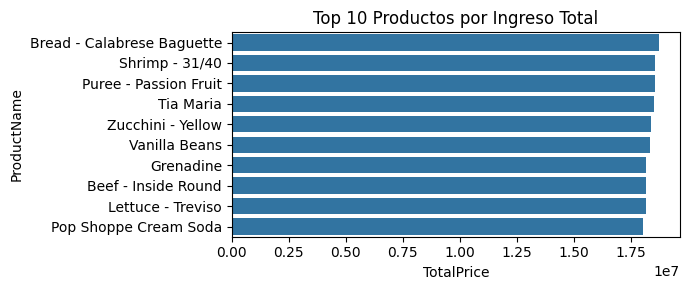

In [57]:
top_10_products = (df_eda.groupby('ProductName')['TotalPrice'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(7,3))
sns.barplot(x=top_10_products.values, y=top_10_products.index)

plt.title('Top 10 Productos por Ingreso Total')
plt.xlabel('TotalPrice')
plt.ylabel('ProductName')

plt.tight_layout()
plt.show()

In [58]:
# Analizaremos la concentración del ingreso. Si existe efecto Pareto 80/20?

# Ingreso total por producto
ingreso_product = df_eda.groupby('ProductName')['TotalPrice'].sum().sort_values(ascending=False)
# Porcentaje acumulado del ingreso
cum_perc = ingreso_product.cumsum() / ingreso_product.sum()
# Cuántos productos generan el 80%
pareto_80 = (cum_perc <= 0.8).sum()
print(pareto_80)

252


### Categorías:

In [59]:
# Buscamos TotalPrice por categoría
top_categories = (df_eda.groupby('CategoryName')['TotalPrice'].sum().sort_values(ascending=False))

# Convertimos en DataFrame
top_categories = top_categories.reset_index()
top_categories.columns = ['CategoryName', 'TotalPrice']

# Calculamos porcentaje sobre el total
total_revenue = top_categories['TotalPrice'].sum()
top_categories['TotalPrice_%'] = (top_categories['TotalPrice'] / total_revenue) * 100

top_categories.round(2)

,CategoryName,TotalPrice,TotalPrice_%
0,Confections,5.513642e+08,12.85
1,Meat,4.879269e+08,11.38
2,Poultry,4.358217e+08,10.16
3,Cereals,4.231247e+08,9.86
4,Snails,3.683437e+08,8.59
5,Produce,3.645161e+08,8.50
6,Beverages,3.628877e+08,8.46
7,Dairy,3.507497e+08,8.18
8,Seafood,3.271988e+08,7.63
9,Grain,3.206268e+08,7.48


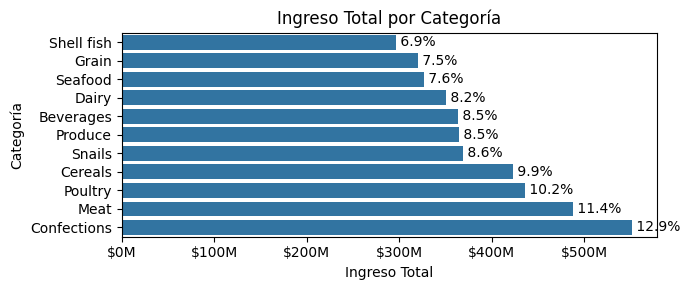

In [60]:
# Ingreso por categoría
category_ingreso = (df_eda.groupby('CategoryName')['TotalPrice'].sum().sort_values(ascending=True).reset_index())
# Calculamos porcentaje
total_revenue = category_ingreso['TotalPrice'].sum()
category_ingreso['Revenue_%'] = (category_ingreso['TotalPrice'] / total_revenue * 100)

plt.figure(figsize=(7,3))
ax = sns.barplot(data=category_ingreso, x='TotalPrice', y='CategoryName')

# Formatear eje X en millones
def millions(x, pos):
    return f'${x/1e6:,.0f}M'
ax.xaxis.set_major_formatter(FuncFormatter(millions))
# Añadir etiquetas con porcentaje
for i, row in category_ingreso.iterrows():
    ax.text(row['TotalPrice'],i,
        f" {row['Revenue_%']:.1f}%",va='center')
plt.title('Ingreso Total por Categoría')
plt.xlabel('Ingreso Total')
plt.ylabel('Categoría')

plt.tight_layout()
plt.show()

#### Pregunta clave 3:  ¿Cómo influyen los descuentos en el comportamiento de compra?

la cantidad promedio vendida es prácticamente igual en transacciones con y sin descuento (13.01 vs 13.00 unidades). Esto indica que los descuentos no generan un aumento significativo en el volumen de compra.

Las transacciones con descuento presentan un ticket promedio de 561.86, frente a 660.88 en ventas sin descuento.
Las ventas con descuento generan ≈ 99 USD o 15% menos por transacción (99.02/660.88 ≈ 0.15).
El descuento está afectando negativamente el ingreso sin incrementar volumen.


- Ingreso total sin descuento: 3.538 M
- Ingreso total con descuento: 751 M
- Total aproximado: 3.538 M + 751 M = 4.289 M
- Ventas sin descuento: 3.538 M/4.289 M ≈ 0.82
- Ventas con descuento: 751 M/4.289 M ≈ 0.18

Los descuentos no incrementan volumen y reducen el ticket promedio.
Representan solo 18%, una parte relativamente pequeña del ingreso total.
Esto sugiere que la estrategia promocional no está siendo altamente efectiva en términos de crecimiento.

Grafico de barras segmentado por categorias nos confirma que la estrategia de descuentos actual parece estar reduciendo el ingreso por transacción en lugar de aumentarlo.

In [61]:
# ¿Aumenta la cantidad vendida cuando hay descuento?
# Creamos variable binaria
df_eda['HasDiscount'] = df_eda['Discount'] > 0

In [62]:
# Comparamos cantidad promedio
df_eda.groupby('HasDiscount')['Quantity'].mean()

HasDiscount
False    13.001829
True     13.011938
Name: Quantity, dtype: float64

In [63]:
# ¿Qué impacto tiene descuento al ingreso final?
# Comparamos ticket promedio
df_eda.groupby('HasDiscount')['TotalPrice'].mean().round(2)

HasDiscount
False    660.88
True     561.86
Name: TotalPrice, dtype: float64

In [64]:
# Impacto en Ingreso total
df_eda.groupby('HasDiscount')['TotalPrice'].sum().round(0)

HasDiscount
False    3.537713e+09
True     7.515288e+08
Name: TotalPrice, dtype: float64

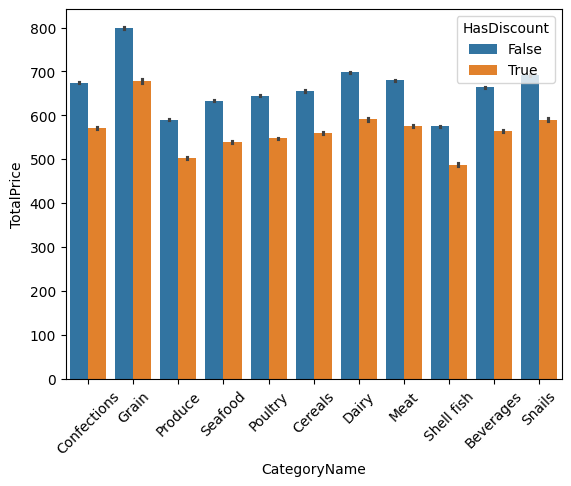

In [65]:
# Barplot agrupado por el ticket promedio (TotalPrice) por categoría segmentando por la presencia o ausencia de descuento.
sns.barplot(data=df_eda, x='CategoryName', y='TotalPrice', hue='HasDiscount')
plt.xticks(rotation=45)
plt.show()

#### Pregunta clave 4:   ¿Existen patrones temporales en las ventas?

**Analisis por meses**

El análisis mensual muestra que las ventas se mantienen bastante estables entre enero y abril de 2018. En febrero se observa una caída cercana al 9.8% (posible efecto calendario — mes más corto), que se recupera en marzo con un crecimiento del 11%. En abril hay una ligera disminución (−3.4%). Además, el Ingreso Total y la Cantidad Vendida cambian casi en la misma proporción, lo que indica que las variaciones en ingresos se deben principalmente al volumen vendido y no a cambios en precios.

**Analisis por días de semana**

Los días con mayor ingreso total son: Miércoles, Lunes y Martes. El fin de semana es ligeramente más débil.
La diferencia aproximada entre el día más fuerte (miércoles) y el más bajo (jueves) es:
631.9M − 597.9M ≈ 34M. Eso es alrededor de un 5% de diferencia.

Las diferencias no son significativas, lo que indica una distribución estable de ventas a lo largo de la semana.

**Analisis por fecha completa**

El gráfico muestra que el negocio presenta la variabilidad diaria es moderada y constante a lo largo del período., sin señales de crecimiento acelerado ni caídas estructurales. Existen picos puntuales (días de alta demanda), pero no son persistentes.

##### Meses

In [66]:
# Para analisis por meses creamos dataset nuevo. 
# Para evitar distorsiones en el análisis temporal, excluimos 9 dias del mes de mayo  para tener los meses completos. 
df_meses = df_eda[df_eda['SalesDate'] < '2018-05-01'].copy()

In [67]:
# Ingresos totales de cada mes
ingreso_por_mes = df_meses.groupby('MonthNum')['TotalPrice'].sum().sort_index()
ingreso_por_mes

MonthNum
1    1.030736e+09
2    9.292043e+08
3    1.032201e+09
4    9.972686e+08
Name: TotalPrice, dtype: float64

In [68]:
# Número total de unidades vendidas cada mes
ventas_por_mes = df_meses.groupby('MonthNum')['Quantity'].sum().sort_index()
ventas_por_mes

MonthNum
1    20900454
2    18862843
3    20930945
4    20229466
Name: Quantity, dtype: int64

In [69]:
cambio_ingresos = (ingreso_por_mes.pct_change() * 100)
cambio_ingresos

MonthNum
1          NaN
2    -9.850407
3    11.084384
4    -3.384252
Name: TotalPrice, dtype: float64

In [70]:
cambio_ventas = ventas_por_mes.pct_change() * 100
cambio_ventas

MonthNum
1          NaN
2    -9.749123
3    10.963893
4    -3.351397
Name: Quantity, dtype: float64

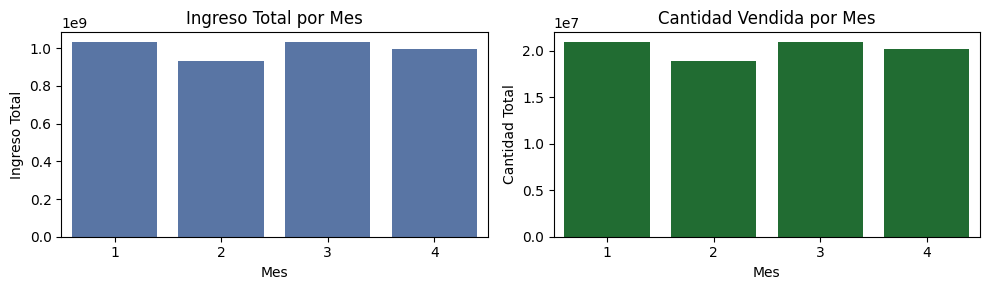

In [71]:
# Interpretación gráfica:
fig, axes = plt.subplots(1, 2, figsize=(10,3))

# Ingreso Total
sns.barplot(x=ingreso_por_mes.index,y=ingreso_por_mes.values,ax=axes[0],color="#4C72B0")

axes[0].set_title('Ingreso Total por Mes')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Ingreso Total')

# Cantidad vendida
sns.barplot(x=ventas_por_mes.index,y=ventas_por_mes.values,ax=axes[1],color="#14792B")

axes[1].set_title('Cantidad Vendida por Mes')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Cantidad Total')

plt.tight_layout()
plt.show()

##### Días de semana

In [72]:
# Para el analisis usamos el conjunto de datos completo df_eda
# Ingresos totales por día de la semana
ingreso_por_dia = df_eda.groupby('DayOfWeek')['TotalPrice'].sum().sort_values(ascending=False)
ingreso_por_dia

DayOfWeek
Wednesday    6.318888e+08
Monday       6.316623e+08
Tuesday      6.310675e+08
Friday       5.993266e+08
Sunday       5.988446e+08
Saturday     5.984982e+08
Thursday     5.979540e+08
Name: TotalPrice, dtype: float64

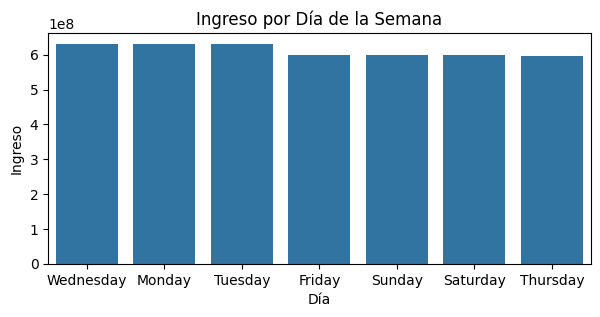

In [73]:
# Interpretación grafica:
plt.figure(figsize=(7,3))
sns.barplot(x=ingreso_por_dia.index, y=ingreso_por_dia.values)
plt.title('Ingreso por Día de la Semana')
plt.xlabel('Día')
plt.ylabel('Ingreso')
plt.show()

##### Fecha completa

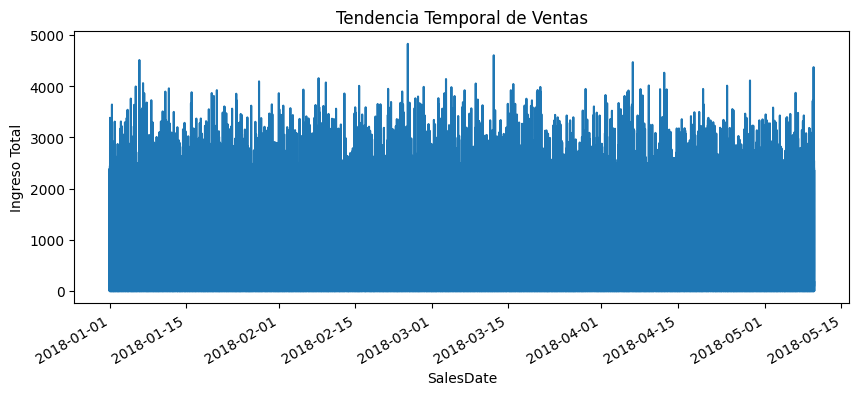

In [74]:
# Analizamos por fecha completa.
sales_trend = df_eda.groupby('SalesDate')['TotalPrice'].sum()

plt.figure(figsize=(10,4))
sales_trend.plot()
plt.title('Tendencia Temporal de Ventas')
plt.ylabel('Ingreso Total')
plt.show()

#### Pregunta clave 5:   ¿Donde se generan los valores más altos de ventas?

**Análisis TOP 10 Ciudades por Ingreso Total**

El ingreso está distribuido de manera homogénea entre las principales ciudades. Ninguna ciudad domina significativamente las ventas, ya que incluso la primera representa apenas el 1.13% del total. Esto indica una estructura geográfica diversificada y sin alta dependencia regional.

**Análisis TOP 10 vendedores**

El análisis muestra una distribución altamente homogénea de las ventas entre vendedores. No existen diferencias significativas en ingreso, volumen ni ticket promedio, lo que indica un modelo de ventas estandarizado sin alta dependencia de vendedores individuales.

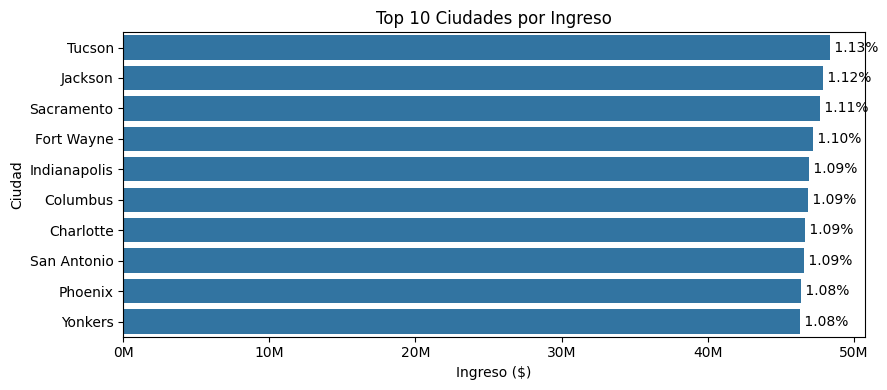

In [75]:
# Ingreso por ciudad
ingreso_city = df_eda.groupby('CityName')['TotalPrice'].sum().sort_values(ascending=False).reset_index()

# % sobre Ingreso total
total_ingreso = ingreso_city['TotalPrice'].sum()
ingreso_city['Ingreso_%'] = (ingreso_city['TotalPrice'] / total_ingreso) * 100

# Top 10 ciudades
top10_city = ingreso_city.head(10)

# Gráfico horizontal
plt.figure(figsize=(9,4))

ax = sns.barplot(data=top10_city,y='CityName',x='TotalPrice')

plt.title('Top 10 Ciudades por Ingreso')
plt.xlabel('Ingreso ($)')
plt.ylabel('Ciudad')

# Formatear eje X en millones
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Añadir etiquetas con %
for i, row in top10_city.iterrows():
    plt.text(row['TotalPrice'],i,f" {row['Ingreso_%']:.2f}%",va='center')

plt.tight_layout()
plt.show()

In [76]:
# Análisis de vendedores
sales_table = df_eda.groupby('SalesPersonID').agg(
        Ingreso_Total=('TotalPrice', 'sum'),
        Ventas_Total=('Quantity', 'sum'),
        Num_Transacciones=('TotalPrice', 'count')
    )

# Ticket promedio
sales_table['Ticket_Promedio'] = (sales_table['Ingreso_Total'] / sales_table['Num_Transacciones']).round(2)

# % sobre ingreso total
total_revenue = sales_table['Ingreso_Total'].sum()
sales_table['Ingreso_%'] = (sales_table['Ingreso_Total'] / total_revenue * 100).round(2)

# Ordenar por ingreso
sales_table = sales_table.sort_values(by='Ingreso_Total',ascending=False)

sales_table.head(10)

,Ingreso_Total,Ventas_Total,Num_Transacciones,Ticket_Promedio,Ingreso_%
SalesPersonID,,,,,
21,1.881669e+08,3803313,292024,644.35,4.39
20,1.875821e+08,3781726,290669,645.35,4.37
13,1.874378e+08,3785142,290633,644.93,4.37
5,1.872717e+08,3781780,290729,644.15,4.37
4,1.872143e+08,3792135,291767,641.66,4.36
8,1.870501e+08,3795049,291545,641.58,4.36
14,1.870400e+08,3782774,290936,642.89,4.36
7,1.869351e+08,3781949,291037,642.31,4.36
22,1.869255e+08,3781176,290261,643.99,4.36
